In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
df = pd.read_csv("employee_attrition.csv")

In [3]:
df.head()

,Age,MonthlyIncome,JobSatisfaction,YearsAtCompany,OverTime,JobLevel,WorkLifeBalance,DistanceFromHome,Attrition
0,60,8364,3,11,Yes,5,2,27,No
1,50,11974,4,18,No,5,1,4,No
2,36,10026,2,14,No,2,2,29,No
3,29,11401,1,1,No,3,3,6,Yes
4,42,8075,3,1,No,3,3,25,Yes


In [4]:
df.shape

(150, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               150 non-null    int64 
 1   MonthlyIncome     150 non-null    int64 
 2   JobSatisfaction   150 non-null    int64 
 3   YearsAtCompany    150 non-null    int64 
 4   OverTime          150 non-null    object
 5   JobLevel          150 non-null    int64 
 6   WorkLifeBalance   150 non-null    int64 
 7   DistanceFromHome  150 non-null    int64 
 8   Attrition         150 non-null    object
dtypes: int64(7), object(2)
memory usage: 10.7+ KB


In [6]:
df.describe()

,Age,MonthlyIncome,JobSatisfaction,YearsAtCompany,JobLevel,WorkLifeBalance,DistanceFromHome
count,150.00000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,41.34000,10095.286667,2.506667,9.993333,2.933333,2.453333,15.260000
std,11.50187,4367.248335,1.157100,6.390531,1.388673,1.108761,8.851823
min,22.00000,2697.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,31.25000,6337.500000,1.000000,4.000000,2.000000,1.000000,8.000000
50%,43.00000,9836.000000,2.000000,11.000000,3.000000,2.000000,15.000000
75%,50.00000,14082.000000,4.000000,16.000000,4.000000,3.000000,23.000000
max,60.00000,17732.000000,4.000000,20.000000,5.000000,4.000000,30.000000


In [7]:
df.isnull().sum()

Age                 0
MonthlyIncome       0
JobSatisfaction     0
YearsAtCompany      0
OverTime            0
JobLevel            0
WorkLifeBalance     0
DistanceFromHome    0
Attrition           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Attrition"].value_counts()

Attrition
No     91
Yes    59
Name: count, dtype: int64

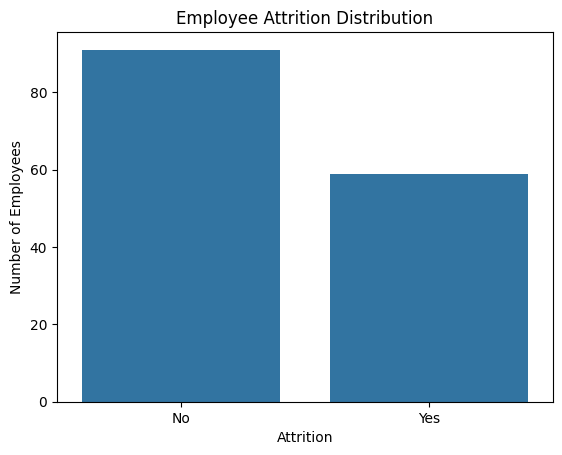

In [10]:
sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [11]:
df.duplicated().sum()
df = df.drop_duplicates()
df.duplicated().sum()



np.int64(0)

In [12]:
df.isnull().sum()

Age                 0
MonthlyIncome       0
JobSatisfaction     0
YearsAtCompany      0
OverTime            0
JobLevel            0
WorkLifeBalance     0
DistanceFromHome    0
Attrition           0
dtype: int64

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

In [14]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [15]:
df.isnull().sum()

Age                 0
MonthlyIncome       0
JobSatisfaction     0
YearsAtCompany      0
OverTime            0
JobLevel            0
WorkLifeBalance     0
DistanceFromHome    0
Attrition           0
dtype: int64

In [16]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [17]:
y = y.map({"No": 0, "Yes": 1})

In [18]:
y.value_counts()

Attrition
0    91
1    59
Name: count, dtype: int64

In [19]:
X.select_dtypes(include="object").columns

Index(['OverTime'], dtype='object')

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
X.head()

,Age,MonthlyIncome,JobSatisfaction,YearsAtCompany,JobLevel,WorkLifeBalance,DistanceFromHome,OverTime_Yes
0,60,8364,3,11,5,2,27,True
1,50,11974,4,18,5,1,4,False
2,36,10026,2,14,2,2,29,False
3,29,11401,1,1,3,3,6,False
4,42,8075,3,1,3,3,25,False


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaler.fit_transform(X_train)

array([[-2.77349378e-01,  1.52729959e+00, -4.28493559e-01,
         7.69130375e-01, -6.24632583e-01,  1.38468118e+00,
         1.84013685e-01, -6.93888666e-01],
       [ 1.27868869e+00,  1.28562161e-01, -4.28493559e-01,
         1.44455959e-01, -1.35235986e+00, -1.35424863e+00,
         7.53128174e-01, -6.93888666e-01],
       [-1.57404777e+00, -8.66750427e-01,  1.31453109e+00,
        -6.36387061e-01, -1.35235986e+00, -1.35424863e+00,
        -1.63715268e+00,  1.44115338e+00],
       [ 3.27776538e-01, -1.15275717e+00, -1.30000588e+00,
         1.23763619e+00, -1.35235986e+00, -1.35424863e+00,
        -1.18186109e+00, -6.93888666e-01],
       [ 5.87116217e-01,  1.36557557e-01,  4.43018765e-01,
        -1.17126453e-02, -1.35235986e+00, -1.35424863e+00,
        -1.29568399e+00, -6.93888666e-01],
       [ 1.62447493e+00,  1.07932897e+00,  4.43018765e-01,
        -9.48724269e-01, -6.24632583e-01, -4.41272025e-01,
        -4.98923702e-01, -6.93888666e-01],
       [ 3.27776538e-01,  1.453285

In [25]:
scaler.transform(X_test)

array([[ 1.10579557,  1.4311264 ,  1.31453109,  1.39380479, -0.62463258,
        -1.35424863,  0.75312817, -0.69388867],
       [-1.05536841, -0.23100222, -1.30000588,  0.76913037,  0.83082198,
        -1.35424863,  1.43606556,  1.44115338],
       [-1.05536841, -1.1947901 ,  1.31453109, -0.94872427, -0.62463258,
        -1.35424863, -0.27127791, -0.69388867],
       [ 1.45158181, -1.35264207, -1.30000588,  1.08146758, -0.62463258,
         0.47170458,  1.54988846, -0.69388867],
       [ 0.67356278, -0.03774208, -0.42849356, -1.41723008,  0.1030947 ,
         1.38468118, -1.29568399, -0.69388867],
       [ 1.01934901,  1.75322664, -1.30000588,  1.08146758,  0.83082198,
        -1.35424863,  0.63930528,  1.44115338],
       [ 1.27868869, -1.27268811,  0.44301876,  0.92529898,  1.55854926,
         0.47170458, -0.7265695 ,  1.44115338],
       [-0.62313562,  0.20280512, -0.42849356,  0.92529898,  0.1030947 ,
         0.47170458, -1.63715268, -0.69388867],
       [-0.19090282,  0.63843999

In [26]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [42]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_prob = tree_model.predict_proba(X_test)[:, 1]

In [38]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

In [46]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [43]:
print("tree_prob:", len(tree_prob))

tree_prob: 30


In [44]:
print("tree_prob first 5 values:", tree_prob[:5])

tree_prob first 5 values: [0.14285714 0.16666667 0.         0.         0.        ]


In [45]:
print("logistic_prob:", len(logistic_prob))
print("tree_prob:", len(tree_prob))
print("forest_prob:", len(forest_prob))
print("knn_prob:", len(knn_prob))

logistic_prob: 30
tree_prob: 30
forest_prob: 30
knn_prob: 30


In [47]:
results = {
    "Logistic Regression": evaluate_model(
        y_test, logistic_pred, logistic_prob
    ),
    
    "Decision Tree": evaluate_model(
        y_test, tree_pred, tree_prob
    ),
    
    "Random Forest": evaluate_model(
        y_test, forest_pred, forest_prob
    ),
    
    "KNN": evaluate_model(
        y_test, knn_pred, knn_prob
    )
}

In [48]:
comparison_df = pd.DataFrame(results).T

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.700000,0.714286,0.416667,0.526316,0.671296
Decision Tree,0.633333,0.571429,0.333333,0.421053,0.541667
Random Forest,0.700000,0.714286,0.416667,0.526316,0.604167
KNN,0.733333,0.833333,0.416667,0.555556,0.712963


In [49]:
comparison_df.to_csv(
    "performance_comparison.csv"
)

In [50]:
print("Logistic Regression")
print(classification_report(y_test, logistic_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.89      0.78        18
           1       0.71      0.42      0.53        12

    accuracy                           0.70        30
   macro avg       0.70      0.65      0.65        30
weighted avg       0.70      0.70      0.68        30



In [51]:
print("Decision Tree")
print(classification_report(y_test, tree_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.65      0.83      0.73        18
           1       0.57      0.33      0.42        12

    accuracy                           0.63        30
   macro avg       0.61      0.58      0.58        30
weighted avg       0.62      0.63      0.61        30



In [52]:
print("Random Forest")
print(classification_report(y_test, forest_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.70      0.89      0.78        18
           1       0.71      0.42      0.53        12

    accuracy                           0.70        30
   macro avg       0.70      0.65      0.65        30
weighted avg       0.70      0.70      0.68        30



In [53]:
print("KNN")
print(classification_report(y_test, knn_pred))

KNN
              precision    recall  f1-score   support

           0       0.71      0.94      0.81        18
           1       0.83      0.42      0.56        12

    accuracy                           0.73        30
   macro avg       0.77      0.68      0.68        30
weighted avg       0.76      0.73      0.71        30



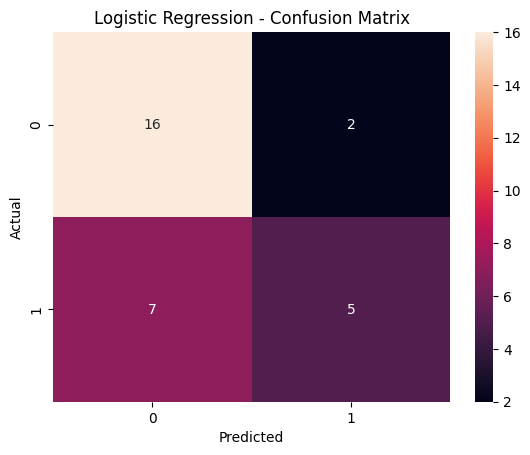

In [54]:
cm = confusion_matrix(y_test, logistic_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

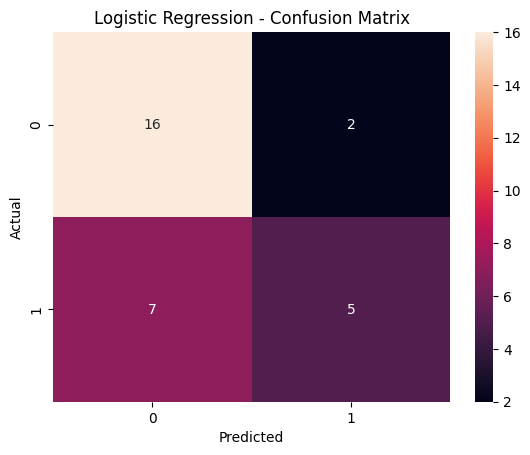

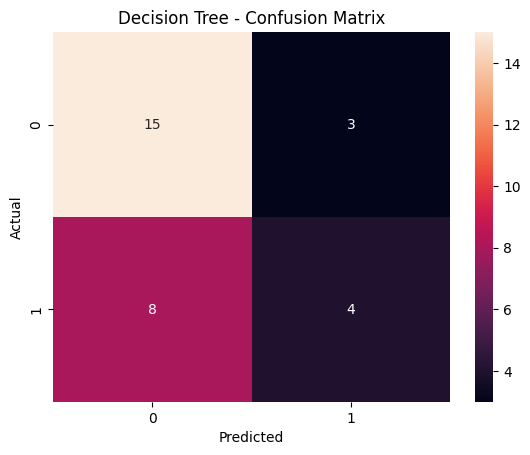

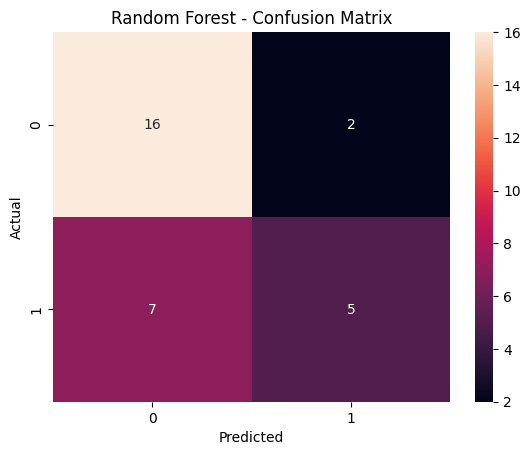

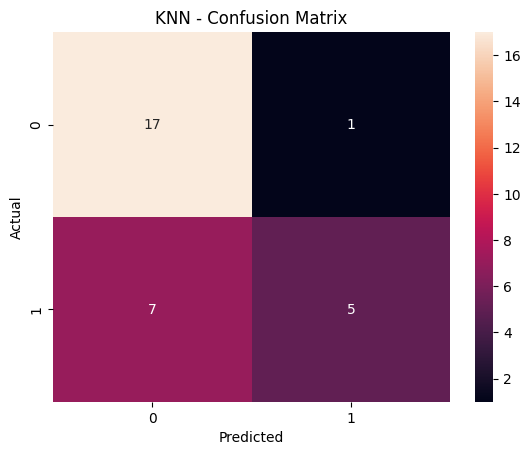

In [55]:
models_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred,
    "KNN": knn_pred
}

for name, predictions in models_predictions.items():
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(cm, annot=True, fmt="d")

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

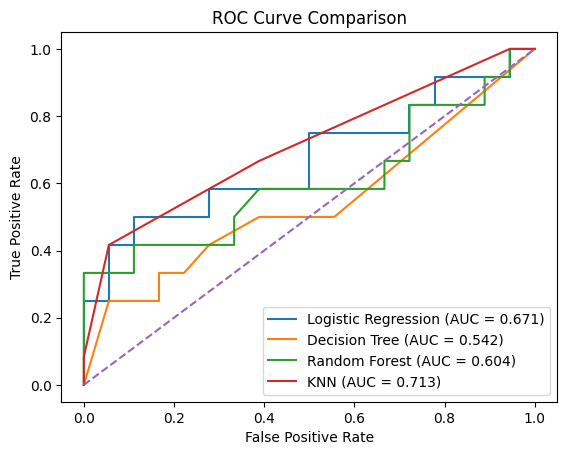

In [56]:
models_probabilities = {
    "Logistic Regression": logistic_prob,
    "Decision Tree": tree_prob,
    "Random Forest": forest_prob,
    "KNN": knn_prob
}

for name, probabilities in models_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    
    auc = roc_auc_score(y_test, probabilities)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [57]:
comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
KNN,0.733333,0.833333,0.416667,0.555556,0.712963
Logistic Regression,0.700000,0.714286,0.416667,0.526316,0.671296
Random Forest,0.700000,0.714286,0.416667,0.526316,0.604167
Decision Tree,0.633333,0.571429,0.333333,0.421053,0.541667


In [58]:
comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
KNN,0.733333,0.833333,0.416667,0.555556,0.712963
Logistic Regression,0.700000,0.714286,0.416667,0.526316,0.671296
Random Forest,0.700000,0.714286,0.416667,0.526316,0.604167
Decision Tree,0.633333,0.571429,0.333333,0.421053,0.541667


In [59]:
feature_importance = pd.Series(
    forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

MonthlyIncome       0.198212
Age                 0.177211
YearsAtCompany      0.137926
DistanceFromHome    0.137380
JobLevel            0.118807
JobSatisfaction     0.083867
OverTime_Yes        0.080316
WorkLifeBalance     0.066280
dtype: float64

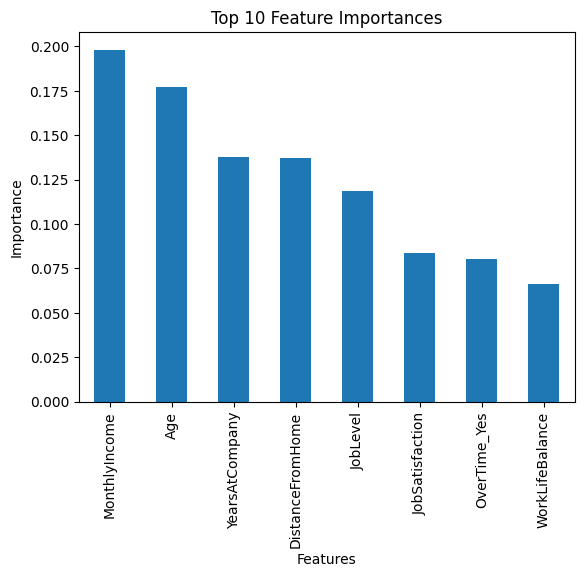

In [60]:
feature_importance.head(10).plot(
    kind="bar",
    title="Top 10 Feature Importances"
)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [61]:
best_model = forest_model

In [62]:
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']